# Supply Chain Control Tower
## Delivery Risk, Profitability & Operational Intelligence

### An End-to-End Supply Chain Data Analysis

##Supply Chain Performance & Risk Analysis

This project analyzes supply chain operations to understand sales, profitability, customer demand, product performance, and delivery efficiency.

The analysis will focus on identifying operational patterns, delivery risks, profitable and loss-making areas, and factors that may affect overall supply chain performance.

The project will use Python for data preparation, analysis, visualization, and interactive exploration.

##Business Questions

The analysis will explore questions such as:

*   How are sales and profits changing over time?
Which products and categories
*   Which products and categories
perform best?
*   Which regions and markets generate the most business?
*   How does shipping mode affect delivery performance?
*   Where are late deliveries most common?
*   Which customer segments contribute the most revenue and profit?
*   Are discounts affecting profitability?
*   Which areas of the supply chain require attention?

In [62]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [63]:
url = "https://raw.githubusercontent.com/ashishpatel26/DataCo-SMART-SUPPLY-CHAIN-FOR-BIG-DATA-ANALYSIS/main/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    url,
    encoding="latin1"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 2. Dataset Overview
This dataset contains transaction-level supply chain data covering orders, customers, products, sales, profitability, shipping, and delivery information.

Before analysing the data, we'll understand its structure, size, key entities, and the information available in each group of columns.

In [64]:
df.shape

(180519, 53)

In [65]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [66]:
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.0,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.0,7,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.0,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.0,7,Fan Shop,41.629959,-72.967155,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.0,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.0,7,Fan Shop,18.213350,-66.370575,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.0,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.0,7,Fan Shop,18.290380,-66.370613,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.0,0.04,65113,399.980011,0.44,1,399.980011,383.980011,168.949997,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [68]:
df.dtypes

,0
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object


In [69]:
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Total rows: 180519
Total columns: 53


In [70]:
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols = df.select_dtypes(include=np.number).columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numeric_cols))

Categorical columns: 24
Numerical columns: 29


The dataset is recorded at the order-item level, so an order can contain multiple items and the same customer or product can appear in multiple records.

In [71]:
# Check the number of unique business entities at different levels
print("Unique Orders:", df["Order Id"].nunique())
print("Unique Order Items:", df["Order Item Id"].nunique())
print("Unique Customers:", df["Customer Id"].nunique())
print("Unique Products:", df["Product Card Id"].nunique())

Unique Orders: 65752
Unique Order Items: 180519
Unique Customers: 20652
Unique Products: 118


In [72]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [73]:
order_item_counts = df.groupby("Order Id")["Order Item Id"].count()

print("Average items per order:", order_item_counts.mean())
print("Maximum items in one order:", order_item_counts.max())
print("Orders with more than 1 item:", (order_item_counts > 1).sum())

Average items per order: 2.745452609806546
Maximum items in one order: 5
Orders with more than 1 item: 45902


In [74]:
categorical_cols = df.select_dtypes(include="object").columns

print("Number of categorical columns:", len(categorical_cols))

print("\nCategorical columns:")
for col in categorical_cols:
    print("-", col)

Number of categorical columns: 24

Categorical columns:
- Type
- Delivery Status
- Category Name
- Customer City
- Customer Country
- Customer Email
- Customer Fname
- Customer Lname
- Customer Password
- Customer Segment
- Customer State
- Customer Street
- Department Name
- Market
- Order City
- Order Country
- order date (DateOrders)
- Order Region
- Order State
- Order Status
- Product Image
- Product Name
- shipping date (DateOrders)
- Shipping Mode


In [75]:
# Examine the main business categories used for operational analysis
important_columns = [
    "Type",
    "Delivery Status",
    "Order Status",
    "Customer Segment",
    "Market",
    "Order Region",
    "Category Name",
    "Department Name",
    "Shipping Mode"
]

for col in important_columns:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    print(df[col].value_counts(dropna=False))


Type
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Delivery Status
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Order Status
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Customer Segment
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Market
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

Order Region
Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia     

In [76]:
date_cols = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

df[date_cols].head()

,order date (DateOrders),shipping date (DateOrders)
0,1/31/2018 22:56,2/3/2018 22:56
1,1/13/2018 12:27,1/18/2018 12:27
2,1/13/2018 12:06,1/17/2018 12:06
3,1/13/2018 11:45,1/16/2018 11:45
4,1/13/2018 11:24,1/15/2018 11:24


In [77]:
financial_columns = [
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "Benefit per order",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Profit Ratio",
    "Product Price"
]

df[financial_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990
Order Item Total,180519.0,183.107609,120.043670,7.49000,104.379997,163.990005,247.399994,1939.989990
Order Profit Per Order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988
Benefit per order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75000,0.080000,0.270000,0.360000,0.500000
Product Price,180519.0,141.232550,139.732492,9.99000,50.000000,59.990002,199.990005,1999.989990


The dataset contains 180,519 order-item records covering 65,752 orders, 20,652 customers, and 118 products. The order-item structure means that one order can contain multiple records, so order-level metrics will need to be handled separately from item-level metrics.

The dataset contains both categorical and numerical business variables, along with order and shipping dates and several financial measures. The main analytical areas are therefore sales and profitability, customer and product performance, and shipping and delivery operations.

The structure is suitable for deeper data-quality checks and preparation before the main analysis.


# 3. Data Quality Assessment



Before cleaning the dataset, we check where values are missing and how significant the missing data is.

In [78]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing %",
    ascending=False
)

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing %
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


<Axes: title={'center': 'Missing Values by Column'}>

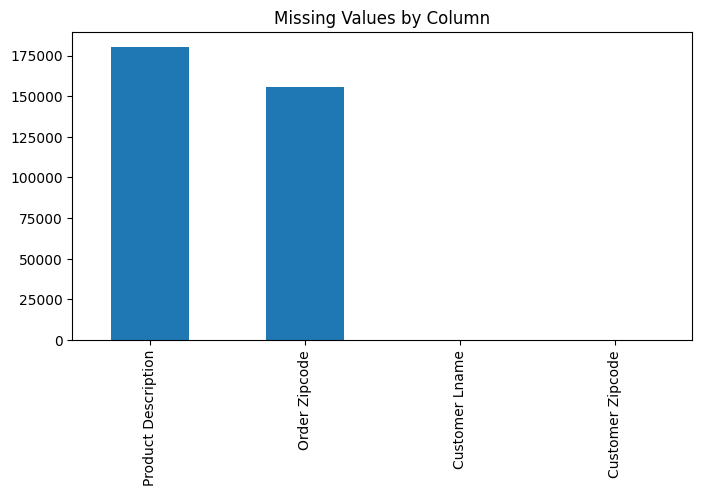

In [79]:
missing_summary[missing_summary["Missing Values"] > 0]["Missing Values"].plot(
    kind="bar",
    figsize=(8, 4),
    title="Missing Values by Column"
)

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
identifier_columns = [
    "Order Id",
    "Order Item Id",
    "Customer Id",
    "Product Card Id"
]

df[identifier_columns].isna().sum()

,0
Order Id,0
Order Item Id,0
Customer Id,0
Product Card Id,0


In [82]:
df[identifier_columns].nunique()

,0
Order Id,65752
Order Item Id,180519
Customer Id,20652
Product Card Id,118


In [83]:
date_cols = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

df[date_cols].dtypes

,0
order date (DateOrders),object
shipping date (DateOrders),object


In [84]:
important_columns = [
    "Type",
    "Delivery Status",
    "Order Status",
    "Customer Segment",
    "Market",
    "Shipping Mode"
]

for col in important_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Type
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Delivery Status
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Order Status
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Customer Segment
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Market
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

Shipping Mode
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [85]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [86]:
print("Late delivery risk:", df["Late_delivery_risk"].unique())
print("Order quantity minimum:", df["Order Item Quantity"].min())
print(
    "Discount rate range:",
    df["Order Item Discount Rate"].min(),
    "to",
    df["Order Item Discount Rate"].max()
)
print("Product status:", df["Product Status"].unique())

Late delivery risk: [0 1]
Order quantity minimum: 1
Discount rate range: 0.0 to 0.25
Product status: [0]


In [87]:
for col in date_cols:
    converted_dates = pd.to_datetime(df[col], errors="coerce")
    print(
        col,
        "— invalid dates:",
        converted_dates.isna().sum()
    )

order date (DateOrders) — invalid dates: 0
shipping date (DateOrders) — invalid dates: 0


In [88]:
#outliers checking
outlier_columns = [
    "Sales",
    "Order Profit Per Order",
    "Order Item Discount",
    "Order Item Product Price"
]

df[outlier_columns].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

,min,25%,50%,75%,max
Sales,9.99000,119.980003,199.919998,299.950012,1999.989990
Order Profit Per Order,-4274.97998,7.000000,31.520000,64.800003,911.799988
Order Item Discount,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Product Price,9.99000,50.000000,59.990002,199.990005,1999.989990


In [89]:
quality_summary = pd.DataFrame({
    "Check": [
        "Total Rows",
        "Exact Duplicate Rows",
        "Columns With Missing Values",
        "Invalid Order Dates",
        "Invalid Shipping Dates"
    ],
    "Result": [
        len(df),
        df.duplicated().sum(),
        df.isna().any().sum(),
        pd.to_datetime(
            df["order date (DateOrders)"],
            errors="coerce"
        ).isna().sum(),
        pd.to_datetime(
            df["shipping date (DateOrders)"],
            errors="coerce"
        ).isna().sum()
    ]
})

quality_summary

,Check,Result
0,Total Rows,180519
1,Exact Duplicate Rows,0
2,Columns With Missing Values,4
3,Invalid Order Dates,0
4,Invalid Shipping Dates,0


The dataset has no exact duplicate records and both date fields contain valid dates. The main data-quality issues are missing values in four columns, including completely empty Product Description and heavily incomplete Order Zipcode.

The numerical checks also show some extreme financial values, particularly in profit and discount. These will be investigated during cleaning rather than removed automatically.

Overall, the dataset is usable, but a few preparation steps are needed before the main analysis.

##DATA CLEANING & PREPARATION

The data-quality checks identified missing values, inconsistent data types, and a few fields that are not useful for analysis. We now prepare a clean analytical dataset while keeping valid business information intact.

In [90]:
# Keep only fields relevant to supply-chain and business analysis
columns_to_drop = [
    "Product Description",
    "Customer Password",
    "Customer Email",
    "Customer Street",
    "Customer Fname",
    "Customer Lname",
    "Product Image"
]

df = df.drop(columns=columns_to_drop)

df.shape

(180519, 46)

In [91]:
df[["Order Zipcode", "Customer Zipcode"]].isna().sum()

,0
Order Zipcode,155679
Customer Zipcode,3


In [92]:
df = df.drop(columns=["Order Zipcode", "Customer Zipcode"])

df.shape

(180519, 44)

In [93]:
date_cols = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [94]:
df[date_cols].dtypes

,0
order date (DateOrders),datetime64[ns]
shipping date (DateOrders),datetime64[ns]


In [95]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.columns.tolist()

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_id',
 'customer_segment',
 'customer_state',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_dateorders',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_name',
 'product_price',
 'product_status',
 'shipping_date_dateorders',
 'shipping_mode']

In [96]:
df.isna().sum()[df.isna().sum() > 0]

,0


In [97]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

Rows: 180519
Columns: 44
Duplicate rows: 0


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   type                         180519 non-null  object        
 1   days_for_shipping_real       180519 non-null  int64         
 2   days_for_shipment_scheduled  180519 non-null  int64         
 3   benefit_per_order            180519 non-null  float64       
 4   sales_per_customer           180519 non-null  float64       
 5   delivery_status              180519 non-null  object        
 6   late_delivery_risk           180519 non-null  int64         
 7   category_id                  180519 non-null  int64         
 8   category_name                180519 non-null  object        
 9   customer_city                180519 non-null  object        
 10  customer_country             180519 non-null  object        
 11  customer_id               

The dataset has been reduced to the fields required for supply-chain analysis. Completely empty and unnecessary personal-information fields were removed, while missing zipcode fields were excluded because they are not required for the core analysis.

The order and shipping dates are now stored as datetime values, and the column names have been standardized for easier analysis.

The cleaned dataset is now ready for feature engineering and exploratory analysis.

##5. FEATURE ENGINEERING

Raw columns give us the basic information, but a few derived metrics will make the business analysis more useful. We'll create features related to delivery performance, profitability, discounts, and time.

In [99]:
df["delivery_delay"] = (
    df["days_for_shipping_real"]
    - df["days_for_shipment_scheduled"]
)

df["delivery_delay"].describe()

,delivery_delay
count,180519.000000
mean,0.565807
std,1.490966
min,-2.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,4.000000


In [100]:
df["profit_margin"] = (
    df["order_profit_per_order"] / df["sales"]
) * 100

df["profit_margin"].describe()

,profit_margin
count,180519.000000
mean,10.832612
std,42.059372
min,-274.999998
25%,6.224000
50%,24.251212
75%,33.601431
max,50.044288


In [101]:
df["order_year"] = df["order_date_dateorders"].dt.year
df["order_month"] = df["order_date_dateorders"].dt.month
df["order_month_name"] = df["order_date_dateorders"].dt.month_name()
df["order_quarter"] = df["order_date_dateorders"].dt.quarter

In [102]:
customer_order_frequency = (
    df.groupby("order_customer_id")["order_id"]
    .nunique()
)

customer_order_frequency.describe()

,order_id
count,20652.000000
mean,3.183808
std,2.430699
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,15.000000


In [103]:
df["customer_order_frequency"] = (
    df["order_customer_id"].map(customer_order_frequency)
)

In [104]:
order_value = (
    df.groupby("order_id")["sales"]
    .sum()
)

df["order_value"] = df["order_id"].map(order_value)

In [105]:
new_features = [
    "delivery_delay",
    "profit_margin",
    "order_year",
    "order_month",
    "order_quarter",
    "customer_order_frequency",
    "order_value"
]

df[new_features].head()

,delivery_delay,profit_margin,order_year,order_month,order_quarter,customer_order_frequency,order_value
0,-1,27.841342,2018,1,1,1,327.75
1,1,-75.999999,2018,1,1,1,327.75
2,0,-75.600305,2018,1,1,1,327.75
3,-1,6.974829,2018,1,1,1,327.75
4,-2,40.948896,2018,1,1,1,327.75


In [106]:
df[new_features].isna().sum()

,0
delivery_delay,0
profit_margin,0
order_year,0
order_month,0
order_quarter,0
customer_order_frequency,0
order_value,0


The new features add useful business context to the raw data. On average, shipments were 0.57 days above the scheduled shipping time, while the median delay was 1 day. Some orders were shipped up to 2 days early, while the maximum delay was 4 days.

The average calculated profit margin was 10.83%, although the wide range indicates substantial variation in profitability across transactions.

Customers placed an average of 3.18 orders, with the highest observed frequency being 15 orders. All newly created features are complete with no missing values.

These features are now ready for the exploratory analysis.

##6. EXPLORATORY DATA ANALYSIS

With the dataset cleaned and the analytical features created, we can now explore the main patterns in sales, profitability, customers, products, and delivery performance.

We’ll focus on findings that can support actual business decisions rather than creating charts just for visualization.

In [107]:
df[["sales", "order_profit_per_order"]].describe().T

,count,mean,std,min,25%,50%,75%,max
sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990
order_profit_per_order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988


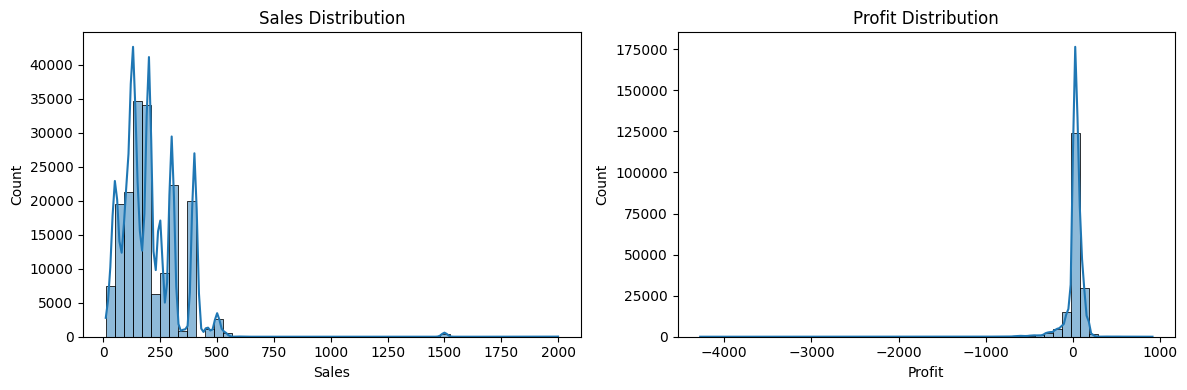

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["sales"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales")

sns.histplot(df["order_profit_per_order"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("Profit")

plt.tight_layout()
plt.show()

In [109]:
yearly_performance = (
    df.groupby("order_year")
      .agg(
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum")
      )
      .reset_index()
)

yearly_performance

,order_year,Sales,Profit
0,2015,1.234083e+07,1.318857e+06
1,2016,1.230382e+07,1.310119e+06
2,2017,1.180844e+07,1.304085e+06
3,2018,3.316501e+05,3.384189e+04


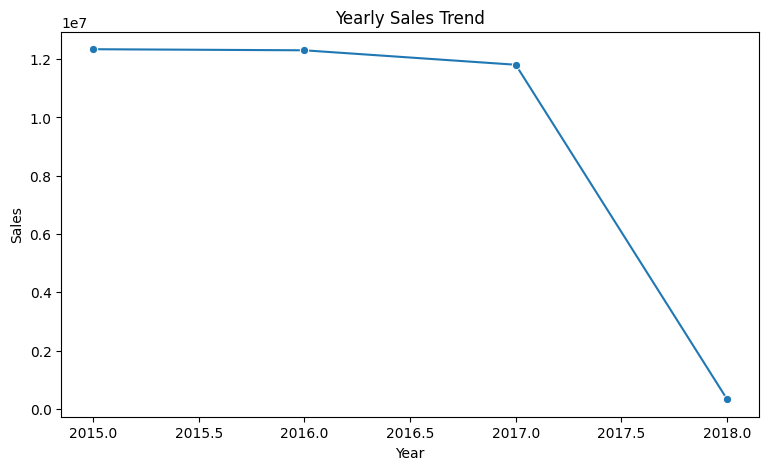

In [110]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly_performance,
    x="order_year",
    y="Sales",
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

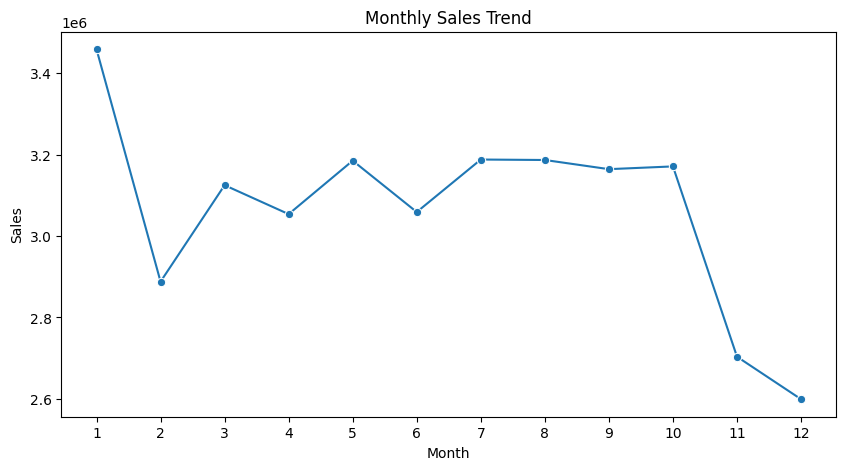

In [111]:
monthly_sales = (
    df.groupby("order_month")
      ["sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_sales,
    x="order_month",
    y="sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1, 13))
plt.show()

In [112]:
category_sales = (
    df.groupby("category_name")["sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales.head(10)

,sales
category_name,
Fishing,6.929654e+06
Cleats,4.431943e+06
Camping & Hiking,4.118426e+06
Cardio Equipment,3.694843e+06
Women's Apparel,3.147800e+06
Water Sports,3.113845e+06
Men's Footwear,2.891758e+06
Indoor/Outdoor Games,2.888994e+06
Shop By Sport,1.309522e+06


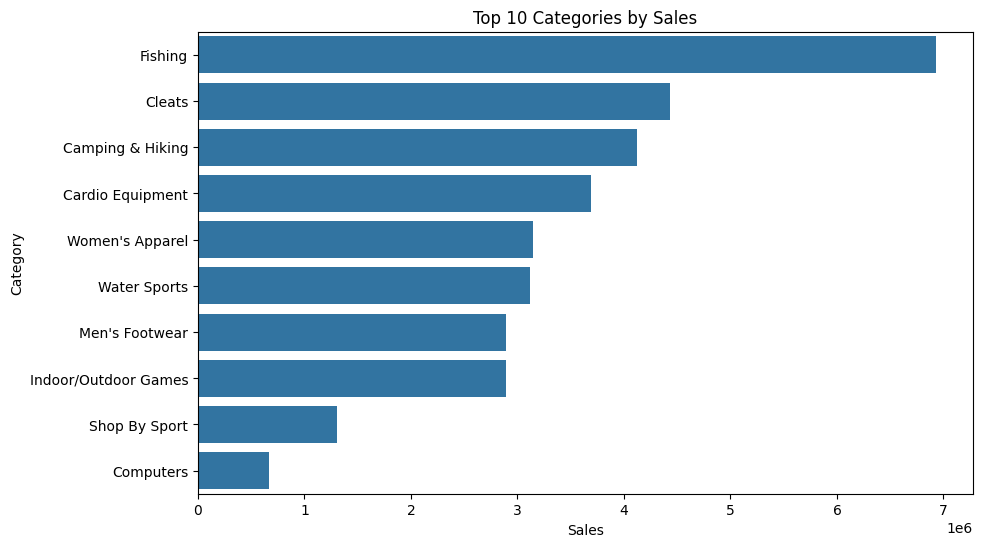

In [113]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.head(10).values,
    y=category_sales.head(10).index
)

plt.title("Top 10 Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

In [114]:
market_sales = (
    df.groupby("market")["sales"]
      .sum()
      .sort_values(ascending=False)
)

market_sales

,sales
market,
Europe,1.087240e+07
LATAM,1.027761e+07
Pacific Asia,8.273744e+06
USCA,5.066529e+06
Africa,2.294453e+06


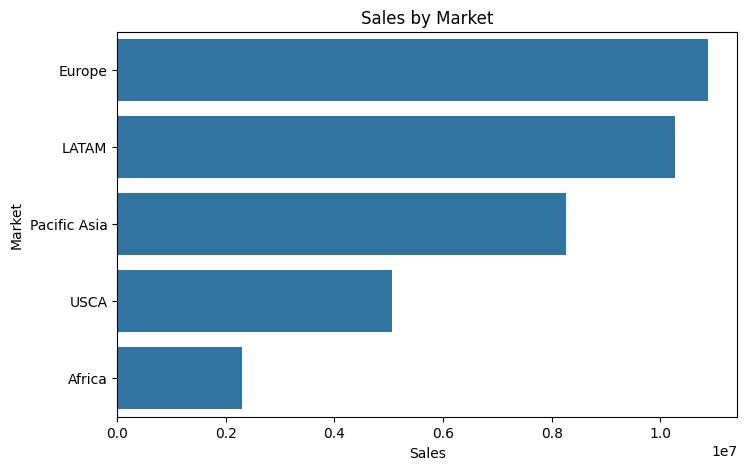

In [115]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=market_sales.values,
    y=market_sales.index
)

plt.title("Sales by Market")
plt.xlabel("Sales")
plt.ylabel("Market")
plt.show()

In [116]:
segment_performance = (
    df.groupby("customer_segment")
      .agg(
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum"),
          Customers=("customer_id", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

segment_performance

,Sales,Profit,Customers
customer_segment,,,
Consumer,1.909579e+07,2.073488e+06,10695
Corporate,1.116841e+07,1.202575e+06,6239
Home Office,6.520538e+06,6.908403e+05,3718


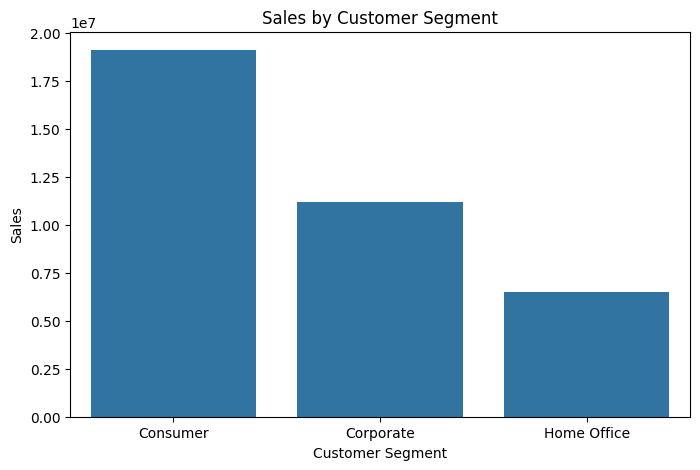

In [117]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_performance.reset_index(),
    x="customer_segment",
    y="Sales"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.show()

In [118]:
shipping_mode_counts = df["shipping_mode"].value_counts()

shipping_mode_counts

,count
shipping_mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737


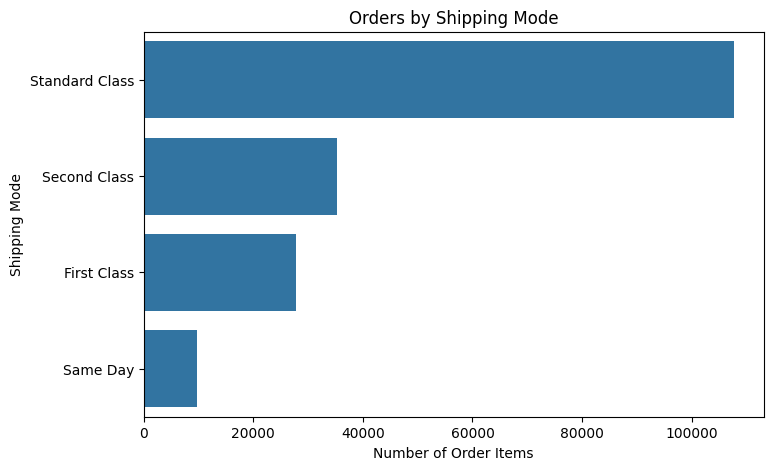

In [119]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=shipping_mode_counts.values,
    y=shipping_mode_counts.index
)

plt.title("Orders by Shipping Mode")
plt.xlabel("Number of Order Items")
plt.ylabel("Shipping Mode")
plt.show()

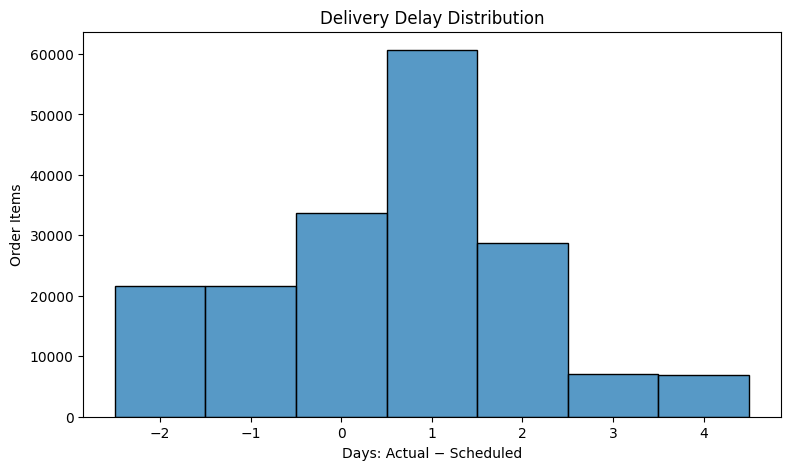

In [120]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["delivery_delay"],
    bins=range(
        int(df["delivery_delay"].min()),
        int(df["delivery_delay"].max()) + 2
    ),
    discrete=True
)

plt.title("Delivery Delay Distribution")
plt.xlabel("Days: Actual − Scheduled")
plt.ylabel("Order Items")
plt.show()

In [121]:
category_profit = (
    df.groupby("category_name")["order_profit_per_order"]
      .sum()
      .sort_values(ascending=False)
)

category_profit.head(10)

,order_profit_per_order
category_name,
Fishing,756220.767190
Cleats,494636.919791
Camping & Hiking,427455.568106
Cardio Equipment,383011.098485
Women's Apparel,350421.029567
Water Sports,325146.960038
Indoor/Outdoor Games,318451.430554
Men's Footwear,311902.820214
Shop By Sport,129813.960315


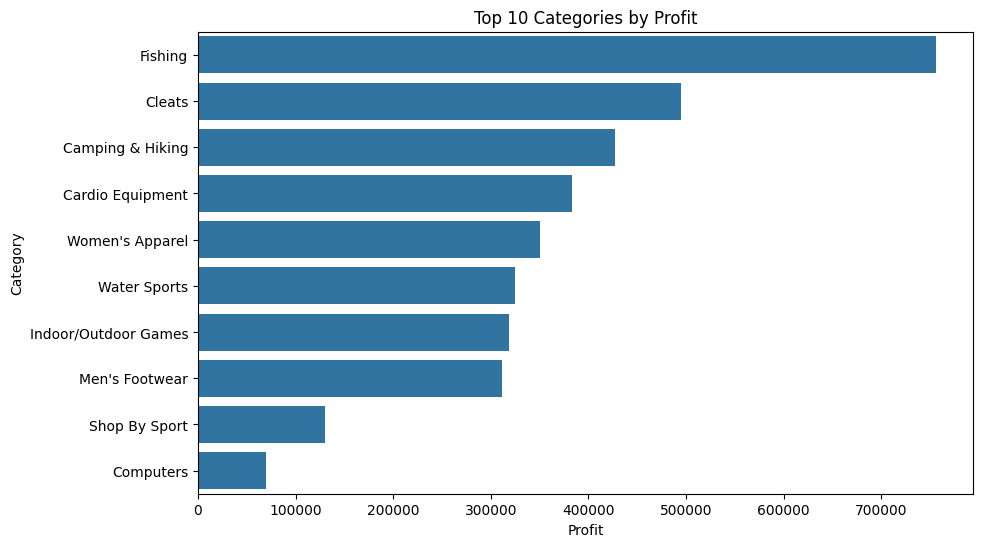

In [122]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_profit.head(10).values,
    y=category_profit.head(10).index
)

plt.title("Top 10 Categories by Profit")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.show()

Sales remained fairly consistent from 2015–2017, with 2015 highest at 12.34M, while 2018 shows a sharp decline that needs further investigation.

Fishing leads both sales at 6.93M and profit at 756K, followed by Cleats and Camping & Hiking.

Europe generated the highest market sales at 10.87M, followed by LATAM at 10.28M, while Africa was lowest at 2.29M.

Consumer customers contributed the most with 19.10M in sales and 2.07M in profit, followed by Corporate and Home Office.

Standard Class dominates shipping with 107,752 order items, making it important for the upcoming delivery-performance analysis.

Overall, the analysis reveals clear differences across categories, markets, customer segments, and shipping methods, which we will investigate further.

##7. SUPPLY CHAIN & DELIVERY ANALYSIS

Delivery performance is a key part of supply-chain operations. In this section, we will identify where delays occur and examine how delivery performance varies across shipping modes, markets, customer segments, and product categories.

In [123]:
delivery_status = df["delivery_status"].value_counts()

delivery_status

,count
delivery_status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


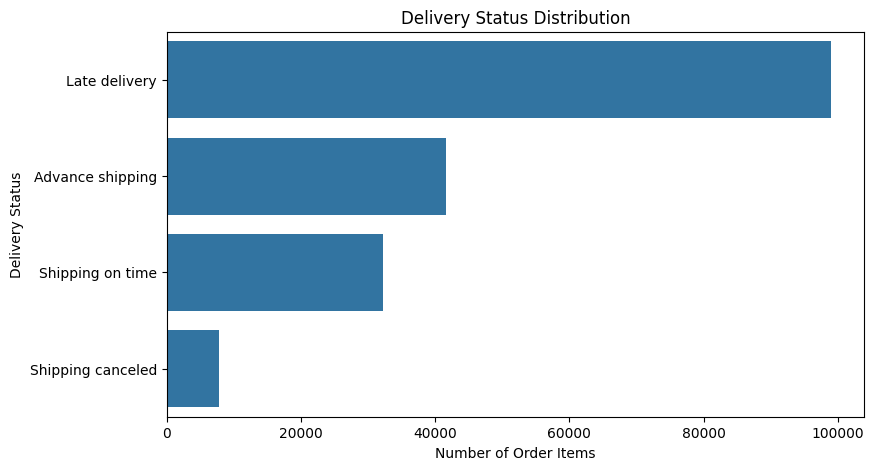

In [124]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=delivery_status.values,
    y=delivery_status.index
)

plt.title("Delivery Status Distribution")
plt.xlabel("Number of Order Items")
plt.ylabel("Delivery Status")
plt.show()

In [125]:
late_risk = df["late_delivery_risk"].value_counts().sort_index()

late_risk

,count
late_delivery_risk,
0,81542
1,98977


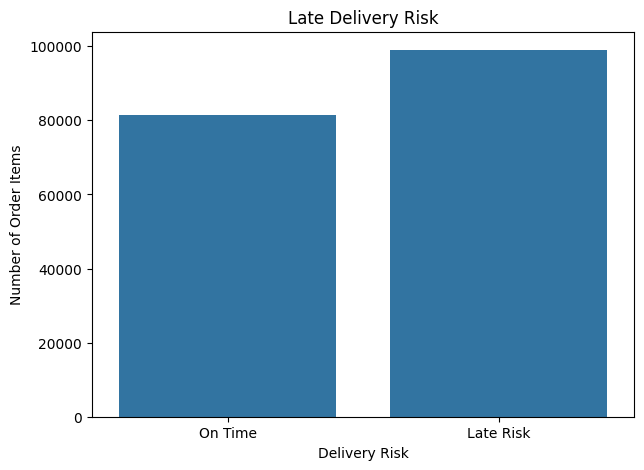

In [126]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=["On Time", "Late Risk"],
    y=late_risk.values
)

plt.title("Late Delivery Risk")
plt.xlabel("Delivery Risk")
plt.ylabel("Number of Order Items")
plt.show()

In [127]:
shipping_performance = (
    df.groupby("shipping_mode")
      .agg(
          Avg_Delay=("delivery_delay", "mean"),
          Late_Risk=("late_delivery_risk", "mean"),
          Order_Items=("order_item_id", "count")
      )
      .sort_values("Avg_Delay", ascending=False)
)

shipping_performance

,Avg_Delay,Late_Risk,Order_Items
shipping_mode,,,
Second Class,1.990828,0.766328,35216
First Class,1.000000,0.953225,27814
Same Day,0.478279,0.457430,9737
Standard Class,-0.004093,0.380717,107752


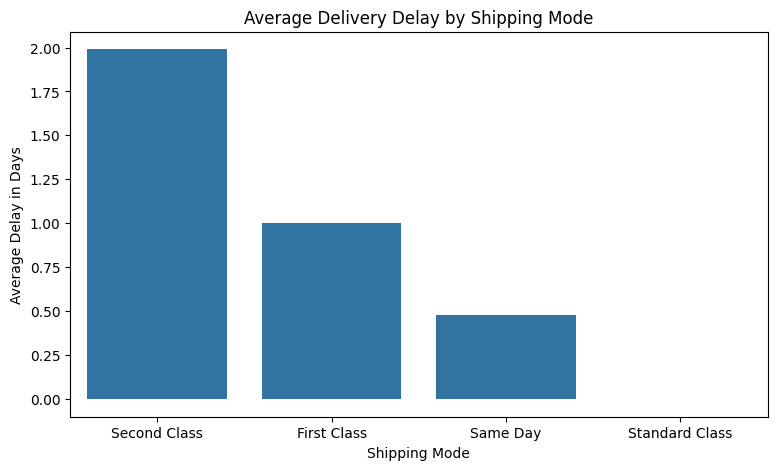

In [128]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=shipping_performance.reset_index(),
    x="shipping_mode",
    y="Avg_Delay"
)

plt.title("Average Delivery Delay by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delay in Days")
plt.show()

In [129]:
market_delivery = (
    df.groupby("market")
      .agg(
          Avg_Delay=("delivery_delay", "mean"),
          Late_Risk=("late_delivery_risk", "mean")
      )
      .sort_values("Avg_Delay", ascending=False)
)

market_delivery

,Avg_Delay,Late_Risk
market,,
Europe,0.570843,0.552078
Pacific Asia,0.569365,0.550460
USCA,0.568859,0.548006
Africa,0.560014,0.545893
LATAM,0.557836,0.543552


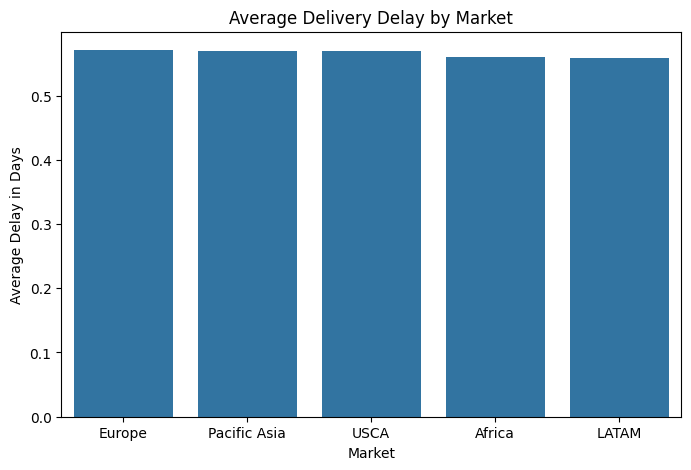

In [130]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=market_delivery.reset_index(),
    x="market",
    y="Avg_Delay"
)

plt.title("Average Delivery Delay by Market")
plt.xlabel("Market")
plt.ylabel("Average Delay in Days")
plt.show()

In [131]:
segment_delivery = (
    df.groupby("customer_segment")
      .agg(
          Avg_Delay=("delivery_delay", "mean"),
          Late_Risk=("late_delivery_risk", "mean")
      )
      .sort_values("Avg_Delay", ascending=False)
)

segment_delivery

,Avg_Delay,Late_Risk
customer_segment,,
Home Office,0.577949,0.550704
Consumer,0.564917,0.548084
Corporate,0.560185,0.547227


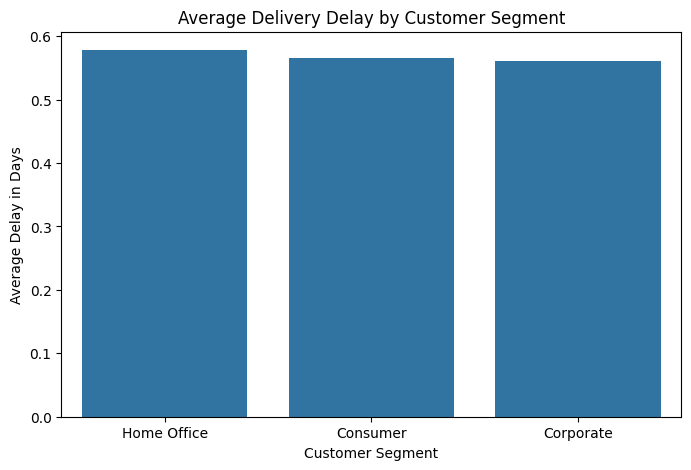

In [136]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_delivery.reset_index(),
    x="customer_segment",
    y="Avg_Delay"
)

plt.title("Average Delivery Delay by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Delay in Days")
plt.show()

In [137]:
category_delivery = (
    df.groupby("category_name")
      .agg(
          Avg_Delay=("delivery_delay", "mean"),
          Late_Risk=("late_delivery_risk", "mean")
      )
      .sort_values("Late_Risk", ascending=False)
)

category_delivery.head(10)

,Avg_Delay,Late_Risk
category_name,,
Golf Bags & Carts,0.770492,0.688525
Lacrosse,0.658892,0.600583
Pet Supplies,0.709350,0.589431
Cameras,0.645270,0.581081
Strength Training,0.666667,0.576577
As Seen on TV!,0.661765,0.573529
Music,0.573733,0.571429
Accessories,0.589326,0.569663
Fitness Accessories,0.614887,0.569579


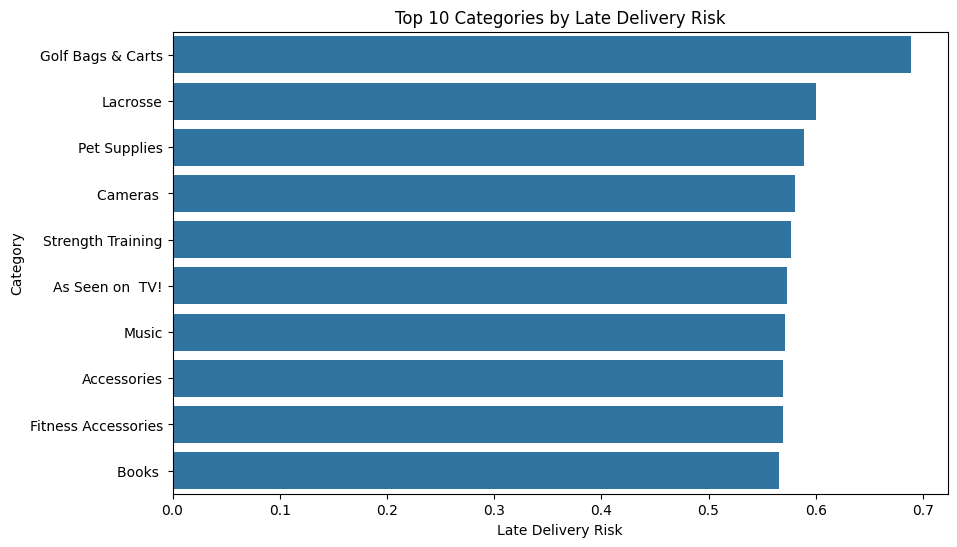

In [138]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_delivery.head(10).reset_index(),
    x="Late_Risk",
    y="category_name"
)

plt.title("Top 10 Categories by Late Delivery Risk")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Category")
plt.show()

In [139]:
delay_profit = (
    df.groupby("delivery_delay")
      .agg(
          Avg_Profit=("order_profit_per_order", "mean"),
          Total_Profit=("order_profit_per_order", "sum"),
          Order_Items=("order_item_id", "count")
      )
      .reset_index()
)

delay_profit

,delivery_delay,Avg_Profit,Total_Profit,Order_Items
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.532021,7.605233e+05,33753
3,1,21.940582,1.330630e+06,60647
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


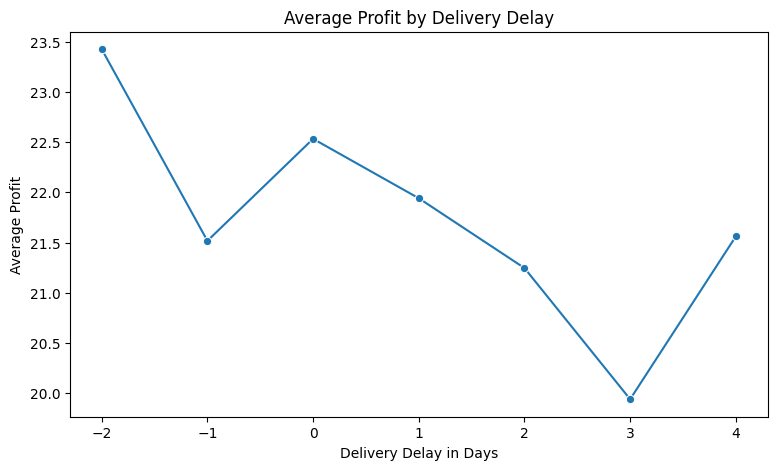

In [140]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=delay_profit,
    x="delivery_delay",
    y="Avg_Profit",
    marker="o"
)

plt.title("Average Profit by Delivery Delay")
plt.xlabel("Delivery Delay in Days")
plt.ylabel("Average Profit")
plt.show()

Late delivery is a major concern, with 98,977 order items classified as late and 54.83% carrying late-delivery risk. Second Class has the highest average delay at 1.99 days, while Standard Class has almost no average delay. Europe has the highest market-level delay, while Home Office customers experience the highest segment-level delay. Golf Bags & Carts has the highest late-delivery risk among the categories analysed at 68.85%. Average profit remains relatively stable across different delay levels, although orders with a 3-day delay generate the highest total profit due to their larger order volume.

##8. Customer Analysis

Customer behaviour is important for understanding purchasing patterns and identifying valuable customer groups. This section analyses order frequency, customer value, and segment performance to understand how customers contribute to overall business performance.

In [141]:
customer_orders = (
    df.groupby("customer_id")["order_id"]
      .nunique()
      .sort_values(ascending=False)
)

customer_orders.describe()

,order_id
count,20652.000000
mean,3.183808
std,2.430699
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,15.000000


In [142]:
customer_value = (
    df.groupby("customer_id")["sales"]
      .sum()
      .sort_values(ascending=False)
)

customer_value.describe()

,sales
count,20652.000000
mean,1781.170589
std,1677.328081
min,11.290000
25%,293.040008
50%,1499.825033
75%,2915.880065
max,10524.170178


In [143]:
top_customers = (
    df.groupby("customer_id")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Orders=("order_id", "nunique"),
          Total_Profit=("order_profit_per_order", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

top_customers.head(10)

,Total_Sales,Total_Orders,Total_Profit
customer_id,,,
791,10524.170178,13,-866.380008
9371,9299.030207,11,1346.579992
8766,9296.140186,11,1495.159984
1657,9223.710152,11,2196.919992
2641,9130.920224,11,2441.970003
1288,9019.110199,12,403.109983
3710,9019.100208,14,1055.130010
4249,8918.850134,13,439.709982
5654,8904.950211,15,1045.359995


In [144]:
customer_segment_analysis = (
    df.groupby("customer_segment")
      .agg(
          Customers=("customer_id", "nunique"),
          Orders=("order_id", "nunique"),
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum")
      )
      .sort_values("Sales", ascending=False)
)

customer_segment_analysis

,Customers,Orders,Sales,Profit
customer_segment,,,,
Consumer,10695,34119,1.909579e+07,2.073488e+06
Corporate,6239,19856,1.116841e+07,1.202575e+06
Home Office,3718,11777,6.520538e+06,6.908403e+05


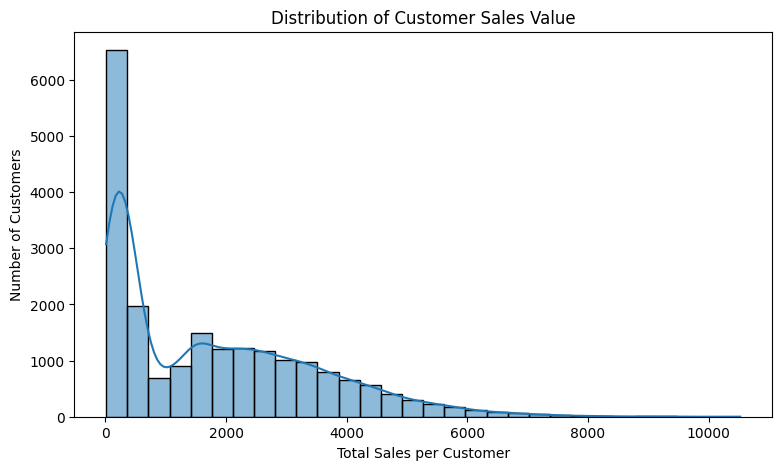

In [145]:
plt.figure(figsize=(9, 5))

sns.histplot(
    customer_value,
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Sales Value")
plt.xlabel("Total Sales per Customer")
plt.ylabel("Number of Customers")
plt.show()

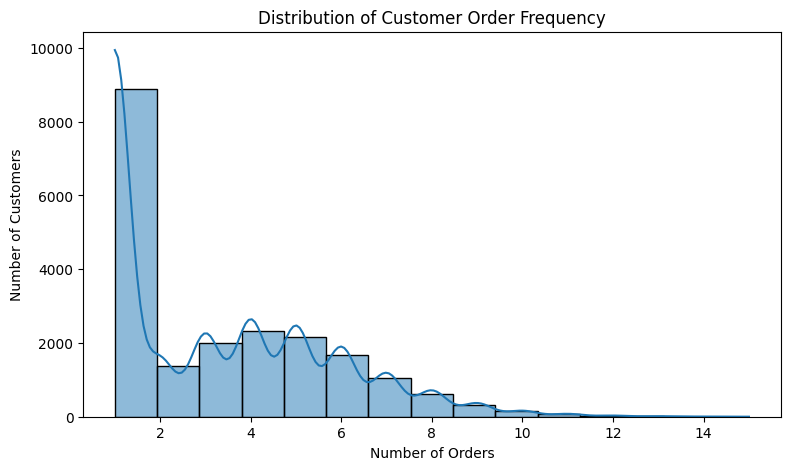

In [146]:
plt.figure(figsize=(9, 5))

sns.histplot(
    customer_orders,
    bins=15,
    kde=True
)

plt.title("Distribution of Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

Customers place an average of 3.18 orders, with the median customer placing 3 orders. Customer sales vary widely, with an average value of 1.78K and the highest reaching 10.52K. The top customer generated 10.52K in sales across 13 orders but recorded a negative profit, showing that high sales do not always mean high profitability. Consumer customers form the largest segment with 10,695 customers and contribute the highest sales at 19.10M and profit at 2.07M, followed by Corporate and Home Office.

##9. Product Analysis

Product-level analysis helps identify which products and categories drive sales and profit. This section focuses on product performance, demand, and profitability to identify strong and weak areas in the product portfolio.

In [147]:
product_sales = (
    df.groupby(["product_card_id", "product_name"])
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("order_profit_per_order", "sum"),
          Order_Items=("order_item_id", "count")
      )
      .sort_values("Total_Sales", ascending=False)
)

product_sales.head(10)

,,Total_Sales,Total_Profit,Order_Items
product_card_id,product_name,,,
1004,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,756220.767190,17325
365,Perfect Fitness Perfect Rip Deck,4.421143e+06,493828.299782,24515
957,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,427455.568106,13729
191,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,379915.818503,12169
502,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,350421.029567,21035
1073,Pelican Sunstream 100 Kayak,3.099845e+06,324076.370020,15500
403,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,311902.820214,22246
1014,O'Brien Men's Neoprene Life Vest,2.888994e+06,318451.430554,19298
627,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,126278.510299,10617


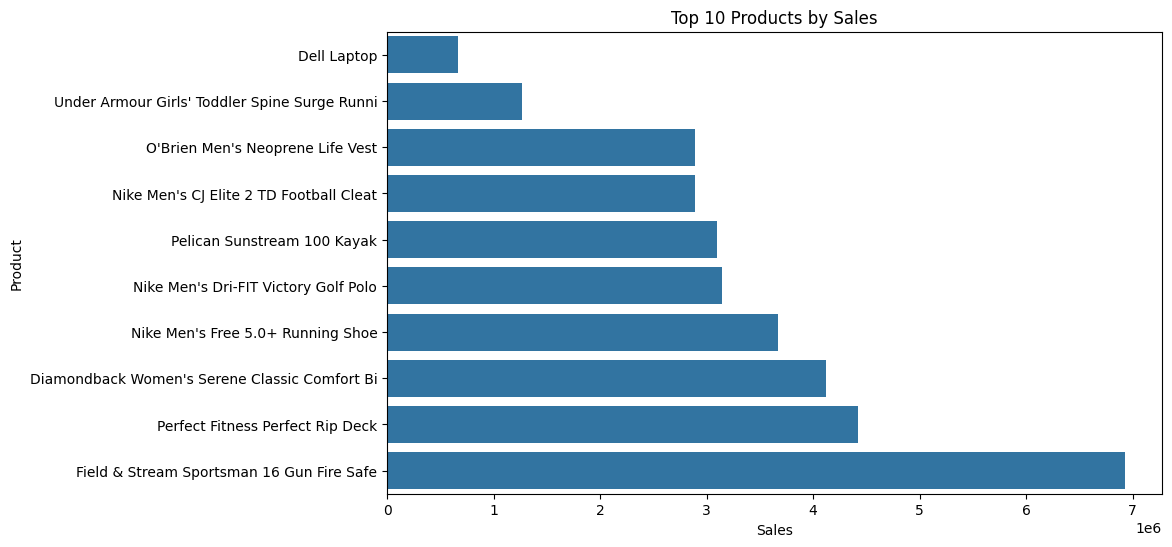

In [167]:
top_products = (
    df.groupby("product_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

In [149]:
product_profit = (
    df.groupby(["product_card_id", "product_name"])
      .agg(
          Total_Profit=("order_profit_per_order", "sum"),
          Avg_Profit=("order_profit_per_order", "mean"),
          Total_Sales=("sales", "sum")
      )
      .sort_values("Total_Profit", ascending=False)
)

product_profit.head(10)

,,Total_Profit,Avg_Profit,Total_Sales
product_card_id,product_name,,,
1004,Field & Stream Sportsman 16 Gun Fire Safe,756220.767190,43.649106,6.929654e+06
365,Perfect Fitness Perfect Rip Deck,493828.299782,20.143924,4.421143e+06
957,Diamondback Women's Serene Classic Comfort Bi,427455.568106,31.135230,4.118426e+06
191,Nike Men's Free 5.0+ Running Shoe,379915.818503,31.219970,3.667633e+06
502,Nike Men's Dri-FIT Victory Golf Polo,350421.029567,16.658951,3.147800e+06
1073,Pelican Sunstream 100 Kayak,324076.370020,20.908153,3.099845e+06
1014,O'Brien Men's Neoprene Life Vest,318451.430554,16.501784,2.888994e+06
403,Nike Men's CJ Elite 2 TD Football Cleat,311902.820214,14.020625,2.891758e+06
627,Under Armour Girls' Toddler Spine Surge Runni,126278.510299,11.893992,1.269083e+06


In [150]:
category_performance = (
    df.groupby("category_name")
      .agg(
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum"),
          Order_Items=("order_item_id", "count")
      )
      .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit,Order_Items
category_name,,,
Fishing,6.929654e+06,756220.767190,17325
Cleats,4.431943e+06,494636.919791,24551
Camping & Hiking,4.118426e+06,427455.568106,13729
Cardio Equipment,3.694843e+06,383011.098485,12487
Women's Apparel,3.147800e+06,350421.029567,21035
Water Sports,3.113845e+06,325146.960038,15540
Men's Footwear,2.891758e+06,311902.820214,22246
Indoor/Outdoor Games,2.888994e+06,318451.430554,19298
Shop By Sport,1.309522e+06,129813.960315,10984


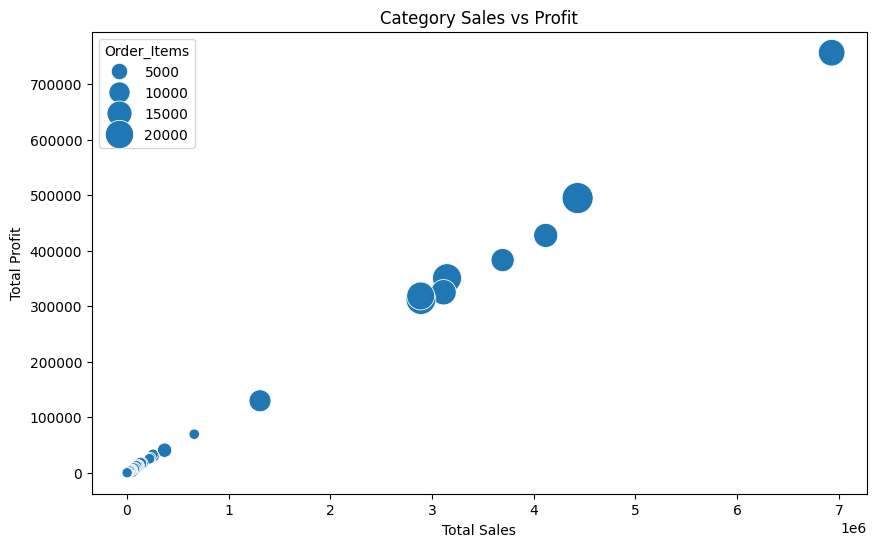

In [151]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_performance.reset_index(),
    x="Sales",
    y="Profit",
    size="Order_Items",
    sizes=(50, 500)
)

plt.title("Category Sales vs Profit")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.show()

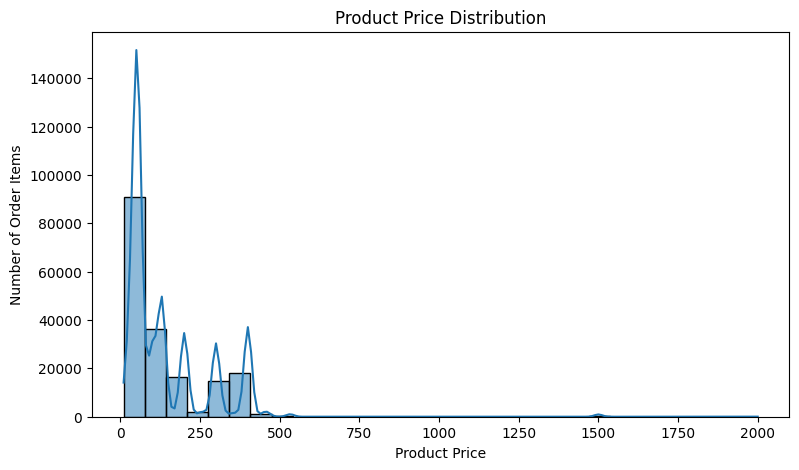

In [152]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["product_price"],
    bins=30,
    kde=True
)

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Number of Order Items")
plt.show()

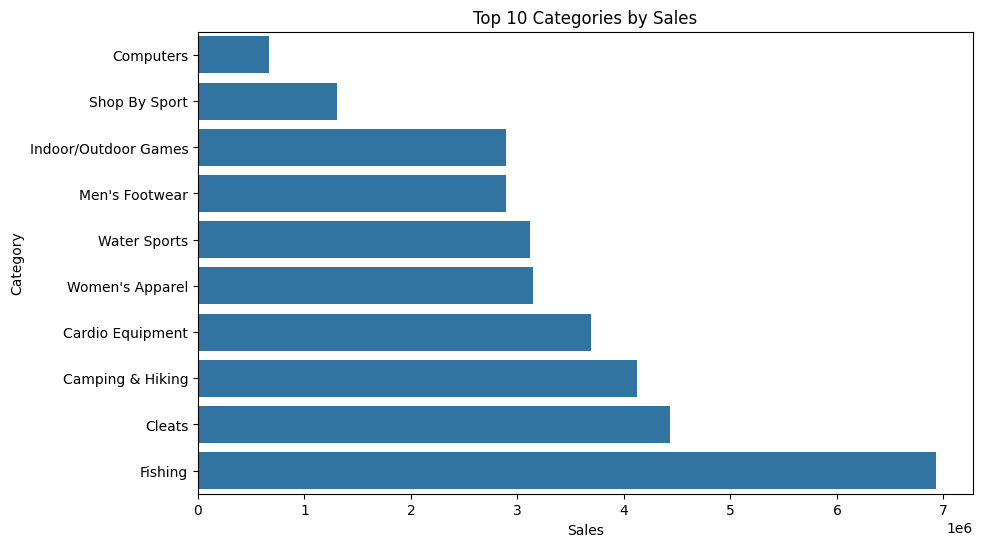

In [165]:
top_categories = (
    df.groupby("category_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

Product analysis shows that the Field & Stream Sportsman 16 Gun Fire Safe is the strongest product, generating 6.93M in sales and 756K in profit. The Perfect Fitness Perfect Rip Deck has the highest order-item volume at 24,515, showing strong demand despite lower average profit per order. Fishing is the top-performing category with 6.93M in sales and 756K in profit, followed by Cleats and Camping & Hiking. Computers generate 663K in sales with only 442 order items, indicating a much higher-value product mix. Overall, product performance varies considerably, with a small group of products and categories contributing a large share of sales and profit.

##10. Time & Trend Analysis

Time-based analysis helps identify changes in sales, profit, and order activity over time. This section examines yearly and monthly trends to understand overall business performance and identify periods that require further investigation.

In [153]:
yearly_performance = (
    df.groupby("order_year")
      .agg(
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum"),
          Orders=("order_id", "nunique")
      )
)

yearly_performance

,Sales,Profit,Orders
order_year,,,
2015,1.234083e+07,1.318857e+06,20904
2016,1.230382e+07,1.310119e+06,20859
2017,1.180844e+07,1.304085e+06,21866
2018,3.316501e+05,3.384189e+04,2123


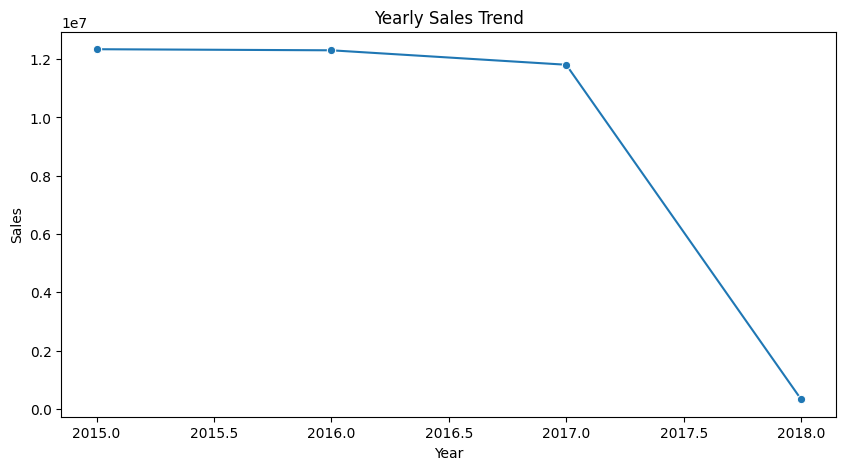

In [164]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_performance.reset_index(),
    x="order_year",
    y="Sales",
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [154]:
monthly_sales = (
    df.groupby(["order_year", "order_month"])["sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,order_year,order_month,sales
0,2015,1,1.051590e+06
1,2015,2,9.270099e+05
2,2015,3,1.051254e+06
3,2015,4,1.014463e+06
4,2015,5,1.050478e+06


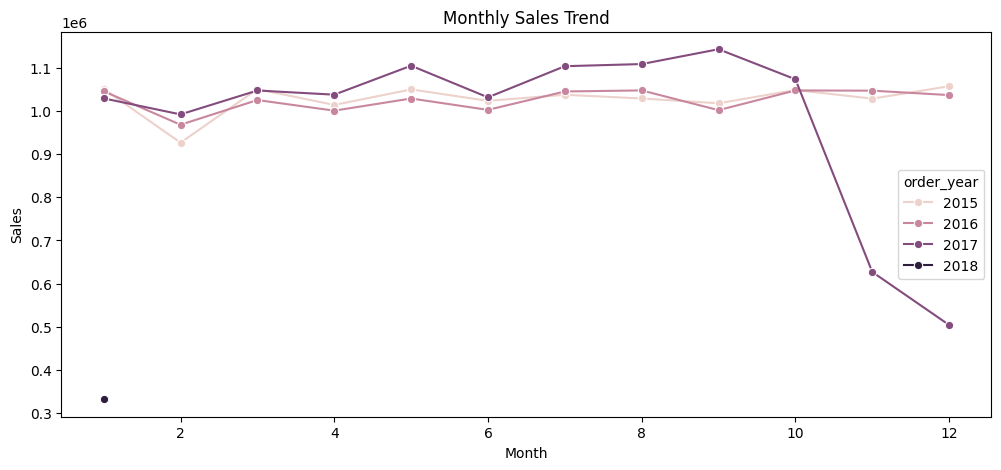

In [155]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="order_month",
    y="sales",
    hue="order_year",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [156]:
monthly_orders = (
    df.groupby(["order_year", "order_month"])["order_id"]
      .nunique()
      .reset_index(name="Orders")
)

monthly_orders.head()

,order_year,order_month,Orders
0,2015,1,1787
1,2015,2,1585
2,2015,3,1781
3,2015,4,1710
4,2015,5,1776


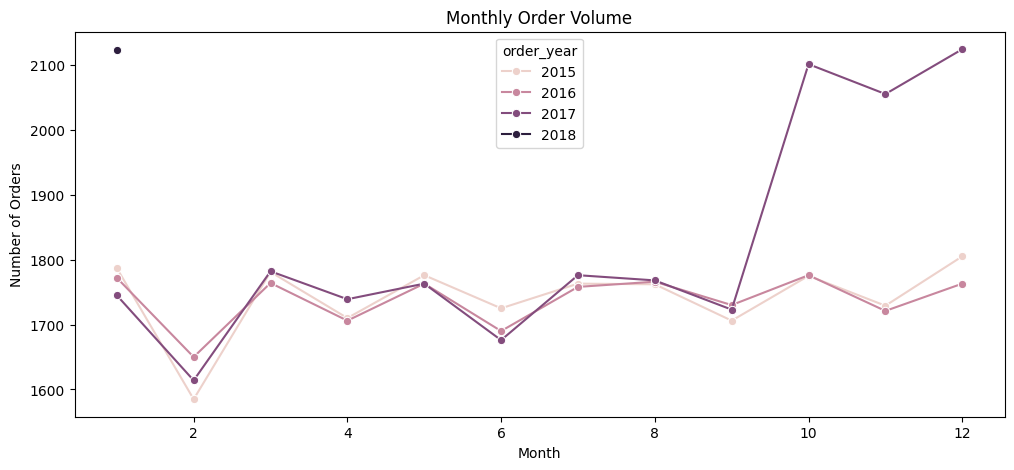

In [157]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_orders,
    x="order_month",
    y="Orders",
    hue="order_year",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

In [158]:
quarterly_performance = (
    df.groupby(["order_year", "order_quarter"])
      .agg(
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum"),
          Orders=("order_id", "nunique")
      )
      .reset_index()
)

quarterly_performance

,order_year,order_quarter,Sales,Profit,Orders
0,2015,1,3.029854e+06,324579.610519,5153
1,2015,2,3.088948e+06,330378.740413,5211
2,2015,3,3.085914e+06,347071.770298,5231
3,2015,4,3.136115e+06,316826.780040,5309
4,2016,1,3.040704e+06,294850.431120,5186
5,2016,2,3.033671e+06,329888.810126,5159
6,2016,3,3.096313e+06,354055.970277,5254
7,2016,4,3.133129e+06,331323.859948,5260
8,2017,1,3.070238e+06,348643.820586,5141
9,2017,2,3.175893e+06,341374.990512,5178


Sales remained relatively stable from 2015 to 2017, with 2015 recording the highest sales at 12.34M. Profit also remained consistent across these years at around 1.3M. 2018 shows a sharp drop in sales, profit, and orders, which may be due to incomplete data for that year. Monthly sales and orders show some variation across periods, but no major seasonal pattern is evident from the available results.

##11. Customer Analysis

Customer-level analysis helps understand purchasing frequency, customer value, and differences between customer segments.

In [159]:
customer_frequency = (
    df.groupby("customer_id")["order_id"]
      .nunique()
      .sort_values(ascending=False)
)

customer_frequency.describe()

,order_id
count,20652.000000
mean,3.183808
std,2.430699
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,15.000000


In [160]:
customer_value = (
    df.groupby("customer_id")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("order_profit_per_order", "sum"),
          Total_Orders=("order_id", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

customer_value.head(10)

,Total_Sales,Total_Profit,Total_Orders
customer_id,,,
791,10524.170178,-866.380008,13
9371,9299.030207,1346.579992,11
8766,9296.140186,1495.159984,11
1657,9223.710152,2196.919992,11
2641,9130.920224,2441.970003,11
1288,9019.110199,403.109983,12
3710,9019.100208,1055.130010,14
4249,8918.850134,439.709982,13
5654,8904.950211,1045.359995,15


In [161]:
segment_performance = (
    df.groupby("customer_segment")
      .agg(
          Customers=("customer_id", "nunique"),
          Orders=("order_id", "nunique"),
          Sales=("sales", "sum"),
          Profit=("order_profit_per_order", "sum")
      )
      .sort_values("Sales", ascending=False)
)

segment_performance

,Customers,Orders,Sales,Profit
customer_segment,,,,
Consumer,10695,34119,1.909579e+07,2.073488e+06
Corporate,6239,19856,1.116841e+07,1.202575e+06
Home Office,3718,11777,6.520538e+06,6.908403e+05


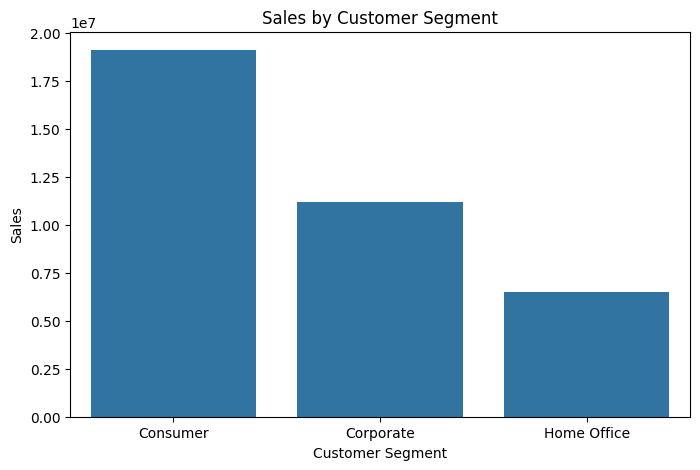

In [166]:
segment_sales = (
    df.groupby("customer_segment")["sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.show()

In [162]:
repeat_customers = (customer_frequency > 1).sum()
total_customers = customer_frequency.nunique()

repeat_customer_rate = repeat_customers / len(customer_frequency) * 100

print("Repeat customers:", repeat_customers)
print("Total customers:", len(customer_frequency))
print("Repeat customer rate:", round(repeat_customer_rate, 2), "%")

Repeat customers: 11768
Total customers: 20652
Repeat customer rate: 56.98 %


In [163]:
top_customers = customer_value.head(10)

top_customers

,Total_Sales,Total_Profit,Total_Orders
customer_id,,,
791,10524.170178,-866.380008,13
9371,9299.030207,1346.579992,11
8766,9296.140186,1495.159984,11
1657,9223.710152,2196.919992,11
2641,9130.920224,2441.970003,11
1288,9019.110199,403.109983,12
3710,9019.100208,1055.130010,14
4249,8918.850134,439.709982,13
5654,8904.950211,1045.359995,15


Customer analysis shows an average of 3.18 orders per customer, with the highest-frequency customers placing up to 15 orders. There are 11,768 repeat customers, giving a repeat customer rate of 56.98%, indicating strong customer retention. Consumer customers form the largest segment with 10,695 customers and contribute 19.10M in sales and 2.07M in profit, followed by Corporate and Home Office. The highest-value customer generated 10,524 in sales across 13 orders but recorded a loss of 866, showing that high sales do not always translate into profitability. Overall, customer value varies significantly, making both sales and profitability important when evaluating customers.

**The analysis shows strong overall sales and profitability, with performance varying across products, markets, customer segments, and delivery operations. Sales remained relatively stable from 2015 to 2017, while 2018 shows a sharp decline that may be linked to incomplete data. Fishing was the strongest category, while Europe generated the highest market sales. Consumer customers contributed the largest share of sales and profit, with a repeat customer rate of 56.98%. Delivery performance is a key area for improvement, as late deliveries account for 98,977 order items. Product performance is concentrated among a smaller group of high-performing products, while some high-sales customers and products require closer profitability monitoring. Overall, the analysis highlights opportunities to improve delivery reliability, monitor pricing and profitability, retain repeat customers, and focus resources on high-performing markets, products, and customer groups.**